# Jupyter Notebook: High Frequency Words of the Christian Standard Bible Corpus

## **Executive Summary**



In this project, I used Python to analyze the Christian Standard Bible. The corpus was cleaned by removing punctuation, duplicate headers, and common filler words to focus on more meaningful terms. Just to see how many words are stopwords in the Bible, I did some calculations on stopwords versus non-stopwords. With just the non-stopword cleaned corpus, I calculated and compared three centrality metrics: Degree, which shows the connections a word has, Betweenness, which shows how often it connects different ideas, and Eigenvector, which shows how influential it is based on its neighbors. I also created visualizations, including frequency and side-by-side bar charts, a Zipf chart, and a network analysis figure to examine how words appear and connect to each other. The network graph shows high density, meaning that words are very closely connected. I broke down the entire workflow process into modules so it can be easily followed and reused.

The data shows clear patterns. After removing stopwords, the analysis focused on the top 200 most frequent meaningful words. "God", "said" and "king: were the most important and influential words in the Bible. They ranked one, two, and three consistently across three centrality metrics. A frequency analysis shows that "God" appears 4,574 times, "Lord" 3,381 times, "king" 3,023 times, "son" 2,957 times, and "said" 2,881 times. After that, the number of times words are frequently found drops off precipitously. The Zipf distribution confirmed a steep drop-off in word frequency, showing that a small number of words dominate the text. Overall, the data demonstrates that influence is not just about frequency. Some words may play a more critical structural role by linking major ideas across the Bible. I found that although "Lord" appears the second most times, "said", and "king" have higher centrality measures.

This research has limitations. Right now, my model only looks at words that appear close together, which doesn’t always capture the full meaning of a sentence or passage. It may be removing some common words that still carry theological significance, depending on context, or including words that may have little significance. The model spots patterns well, but does not understand them like a human reader. Interviewing a biblical scholar and refining the importance of words, understanding biblical grammar and context better, and perhaps analyzing individual books of the Bible would yield interesting results. 

## MODULE 1: Library List

In this module, to keep track of the required libraries used in the project, I listed each one with a short explanation of what each one does.

In [1]:
# LIBRARIES USED IN THIS PROJECT

import pandas as pd  
# Data manipulation and analysis (tables, cleaning, grouping, etc.).

import numpy as np  
# Numerical operations, arrays, and mathematical functions.

import matplotlib.pyplot as plt  
# Data visualization (plots, charts, histograms).

import networkx as nx  
# Network analysis (graphs, centrality measures, relationships between words).

import nltk  
# Natural Language Processing toolkit (tokenization, text processing).

from nltk.corpus import stopwords  
# Predefined list of common words (e.g., "the", "and") to remove from text

from collections import Counter  
# Efficient counting of elements (e.g., word frequencies).

from itertools import combinations  
# Generate combinations of items (used for word co-occurrence networks).

import re  
# Regular expressions for text cleaning and pattern matching.

import requests  
# Used to pull in data from GitHub.

import textwrap  
# Formatting long text strings (useful for plot labels).

import time  
# Performance tracking (timing modules and execution speed).

## MODULE 2: Performance Tracking Utilities

This module defines timing functions used throughout the notebook to measure how long each step of the analysis takes. By capturing start and end times for each module, I am monitoring performance and identifying problems where the pipeline may not run efficiently, especially since I am working with a large text dataset.

In [2]:
# MODULE 2: Performance Tracking Utilities

import time

PIPELINE_START = time.perf_counter()
TIMINGS = []

def start_timer():
    return time.perf_counter()

def end_timer(start, label):
    elapsed = time.perf_counter() - start
    TIMINGS.append((label, elapsed))
    print(f"[TIMER] {label}: {elapsed:.2f} seconds")

## MODULE 3: Load Corpus

This code block loads a bible.txt file that I created from a pdf version of the **[Christian Standard Bible](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://csbible.com/wp-content/uploads/2018/03/CSB_Pew_Bible_2nd_Printing.pdf)**, obtained from The Christian Standard Bible website. I pulled the bible.text file directly from my GitHub repository. Using the requests library, the script retrieves the contents of a Bible text file hosted in my GitHub repository. An issue that needs to be dealt with in the bible.txt file that it contains superfluous front matter that needs to be removed as to not cloud the analysis. The front matter is removed and the remaining text is then stored as a single string to use for all subsequent processing steps. The preview of the first 500 characters is a validation check, confirming that I successfully retrieved the data and get a peek of the structure and content of the corpus before cleaning or transforming. The Counter library counts how many times each word appears in the text. Pandas takes those counts and puts them into a table. Requests gives me the ability to retrieve my file from my GitHub repository.

In [3]:
# Module 3: Load Corpus and trim Bible front matter.

import pandas as pd
from collections import Counter
import requests
import re

url = "https://raw.githubusercontent.com/professorfoy/data620/main/assignment-05-high-frequency-words/bible.txt"

response = requests.get(url)

raw_text = response.text  # keep original for clarity

# Trim the Front Matter: "Genesis" followed by "THE CREATION" (handles spacing/newlines)
match = re.search(r"Genesis\s+THE CREATION", raw_text)

if not match:
    raise ValueError("Start marker not found. Check formatting.")

# Keep only the actual Bible text
text = raw_text[match.start():]

# Preview cleaned text
print(text[:500])

Genesis
THE CREATION
1 
­In ­the be­gin­ning ­God cre­at­ed ­the heav­ens 
­and ­the ­earth. a
2 ­Now ­the ­earth ­was form­less ­and emp­ty, 
dark­ness cov­ered ­the sur­face ­of ­the wa­tery 
­depths, ­and ­the Spir­it ­of ­God ­was hov­er­ing 
­over ­the sur­face ­of ­the wa­ters. 3 ­Then ­God ­said, 
“­Let ­there ­be ­light,” ­and ­there ­was ­light. 4 ­God 
­saw ­that ­the ­light ­was ­good, ­and ­God sep­a­rat­
ed ­the ­light ­from ­the dark­ness. 5 ­God ­called 
­the ­light “­


## MODULE 4: Clean and Tokenize

This module prepares the text so it can be analyzed. All the text is converted to lowercase. Anything that is not a letter, such as punctuation, numbers, or symbols, is removed. The text is split into individual words. Since this corpus came from a pdf converted to a .txt file, there are OCR artifacts clouding the analysis. 

As I printed the top 200 most frequent words, these artifacts appeared. These are partial words. For example, the letters "ord" were appearing as a separate word in the .txt file, but likely were part of the word "Lord". Only after running the top 200 words to all of the broken partial words appear. As they appeared in the top 200 list, I copied and pasted them back into a list of artifict_words and removed them from the analysis.

I also removed the headers and footnotes as they are deemed superfluous data. 

After cleaning and tokenizing the bible.txt file, I have a corpus that can be more properly analyzed. The total number of words is printed. For the bible.txt file, it is 589,965 words.

In [4]:
# Module 4: Clean and Tokenize

import re
start = start_timer()

# Clean text
text = text.lower()
text = re.sub(r'[^a-z\s]', ' ', text)
text = re.sub(r'\s+', ' ', text).strip()

# Tokenize
words = re.findall(r"\b[a-z]+\b", text)

# Remove OCR Artifacts
artifact_words = {
    'one', 'ord', 'ing', 'en', 'er', 'th', 'll', 're', 've', 'ter', 'fore', 'com', 'cause', 'let', 'tion', 'ple', 'peo',
    'ers', 'ther', 'csb', 'der', 'indb', 'mss', 'vid', 'ites', 'oth', 'per', 'fer', 'ses', 'dis', 'ness', 'ser', 
    'mand', 'broth', 'dah', 'ful', 'lem', 'pre', 'mon', 'lis', 'tem', 'proph', 'pro', 'ters', 'spir', 'since', 
    'giv', 'sev', 'wom', 'tions', 'til', 'ment', 'lxx', 'cov', 'ger', 'selves', 'tle', 'bor', 'syr', 'sion', 'dom', 
    'tar', 'plied', 'ings', 'vant', 'heav', 'dan', 'cord', 'ies', 'ble', 'ver', 'daugh', 'fol', 'fam', 'swered', 
    'ered', 'lit', 'ery', 'tain', 'ish', 'add', 'mies', 'tered', 'ples', 'mar', 'jer', 'vants', 'aar', 'wor', 'cor',
    'ward', 'cit', 'sil', 'car', 'gath', 'sis', 'eli', 'res', 'pos', 'ence', 'chil', 'glo', 'ite', 'dren', 'liv',
    'ham', 'sur', 'writ', 'phi', 'sac', 'ben', 'ous', 'moth', 'pha', 'ders', 'less', 'pow', 'fied', 'far', 'mes',
    'min', 'ber', 'raoh', 'pass', 'pres', 'righ', 'teous', 'hun', 'port', 'cob', 'vites', 'wicked', 'tance', 'ished',
    'body', 'ning', 'dants', 'mas', 'thou', 'sen', 'scen', 'mer', 'enant', 'hon', 
}

# remove short fragments + artifacts
words = [
    w for w in words
    if len(w) >= 3 and w not in artifact_words
]

# Remove Headers and Footnotes
book_headers = {
    'genesis','exodus','leviticus','numbers','deuteronomy',
    'joshua','judges','ruth','samuel','kings','chronicles',
    'ezra','nehemiah','esther','job','psalms','proverbs',
    'ecclesiastes','song','isaiah','jeremiah','lamentations',
    'ezekiel','daniel','hosea','joel','amos','obadiah','jonah',
    'micah','nahum','habakkuk','zephaniah','haggai','zechariah',
    'malachi','matthew','mark','luke','john','acts','romans',
    'corinthians','galatians','ephesians','philippians','colossians',
    'thessalonians','timothy','titus','philemon','hebrews',
    'james','peter','jude','revelation'
}

custom_noise = {'lit'}

remove_words = book_headers.union(custom_noise)

words_clean = [w for w in words if w not in remove_words]

end_timer(start, "Tokenization + Cleaning")

print("Total words:", len(words_clean))

[TIMER] Tokenization + Cleaning: 1.10 seconds
Total words: 589965


## MODULE 5: Remove Stopwords

This module removes common stopwords, such as “the,” “and,” or “is.” I used the NLTK library to access a standard list of these words. I filtered the stopwords out of the dataset. The printed counts compare the total number of words before and after removing stopwords, showing the magnitude of the difference with and without them. After removing all the stopwords, I have 322,177 words remaining in the corpus.

In [5]:
# Module 5: Remove Stopwords

start = start_timer()

import nltk

try:
    from nltk.corpus import stopwords
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

words_no_stop = [w for w in words if w not in stop_words]

end_timer(start, "Stopword Removal")

print("Words WITH stopwords:", len(words))
print("Words WITHOUT stopwords:", len(words_no_stop))

[TIMER] Stopword Removal: 84.68 seconds
Words WITH stopwords: 592372
Words WITHOUT stopwords: 322177


## MODULE 6: Unique Words Comparison

This module compares how many unique words are in the text before and after removing stopwords. A unique word means each distinct word is counted only once. Unique word analysis helps understand common filler words versus meaningful terms. If the number of unique words drops significantly after removing stopwords, it probably shows that many of those common words were not adding real value to the analysis. The total unique words WITH stopwords: 14,630, and the total unique WITHOUT stopwords: 14,514. The numbers did not drop significantly, showing that the 14,514 remaining unique words may have significant value.

In [6]:
# Module 6: Unique Words Comparison

start = start_timer()

unique_with = len(set(words))
unique_without = len(set(words_no_stop))

end_timer(start, "Unique Words")

print("Unique WITH stopwords:", unique_with)
print("Unique WITHOUT stopwords:", unique_without)

[TIMER] Unique Words: 0.07 seconds
Unique WITH stopwords: 14630
Unique WITHOUT stopwords: 14514


## MODULE 7: Frequency Analysis (Both Stop and Non-Stop Words)

This module counts how often each word appears in the text relative to the total words. The most frequent words appear at the top. By comparing a nonstop word versus stopword tables, I can see how dramatically removing common filler words reveals the more meaningful concepts that define the content. With the stopwords removed, the word **"God" appears 4,574 times, "Lord" 3,381 times, "king" 3,023 times, "son" 2,957 times and "said" 2,881 times.**

In [7]:
# Module 7: Frequency Analysis for both stop and nonstop words

start = start_timer()

df_with = pd.DataFrame(Counter(words).items(), columns=["word", "count"]).sort_values(by="count", ascending=False)

df_without = pd.DataFrame(Counter(words_no_stop).items(), columns=["word", "count"]).sort_values(by="count", ascending=False)

end_timer(start, "Frequency Analysis")

df_with.head(), df_without.head()

[TIMER] Frequency Analysis: 0.19 seconds


(     word  count
 1     the  57503
 7     and  29285
 127   you  14346
 65   will  10557
 68    for   8878,
      word  count
 3     god   4574
 370  lord   3381
 699  king   3023
 392   son   2957
 14   said   2881)

## MODULE 8: 50% Coverage Comparison (Concentration Ratio)

This module measures how many of the most frequent words are needed to account for 50% of all the words in the text. I did this by adding up word counts from the most common words downward until it reaches half of the total word usage. The result tells me how concentrated the language is. When stopwords are included, only a small number of very common words (like “the” and “and”) usually make up a large portion of the text. After removing stopwords, it typically takes more words to reach that same 50%, showing a richer and more meaningful distribution of vocabulary. 

The reason this step is important is that it helps me understand whether the text is dominated by a few repetitive words or whether it reflects a broader range of ideas. In other words, it quantifies how much real content is present versus how much is just repetition or filler.

The results show a major difference in how concentrated the language is before and after removing stopwords. With stopwords included, only **70 words** are needed to account for 50% of all the words in the text. This indicates that a very small group of common words, mostly filler words like “the,” “and,” and “you”, dominate a large portion of the content. In contrast, after removing stopwords, it takes **394 words** to reach that same 50% coverage. This means the text becomes much more diverse, with many different meaningful words contributing to the overall content.

In [8]:
# Module 8: 50% Coverage Comparison (Concentration Ratio)

start = start_timer()

def coverage(df, total):
    df['cum'] = df['count'].cumsum()
    return (df['cum'] <= total*0.5).sum()

cov_with = coverage(df_with.copy(), len(words))
cov_without = coverage(df_without.copy(), len(words_no_stop))

end_timer(start, "Coverage")

print("WITH stopwords:", cov_with)
print("WITHOUT stopwords:", cov_without)

[TIMER] Coverage: 0.01 seconds
WITH stopwords: 70
WITHOUT stopwords: 394


## MODULE 9: Top 200 Comparison

Compare the most frequent words across both corpora.

In [9]:
# ============================================
# Module 9: TOP 200 WORDS
# ============================================

start = start_timer()

top200_with = df_with.head(200).copy()
top200_without = df_without.head(200).copy()

end_timer(start, "Top 200 Extraction")

# Print just the words (clean list)
print("\nTop 200 Words WITH stopwords:\n")
print(top200_with['word'].tolist())

print("\nTop 200 Words WITHOUT stopwords:\n")
print(top200_without['word'].tolist())

[TIMER] Top 200 Extraction: 0.00 seconds

Top 200 Words WITH stopwords:

['the', 'and', 'you', 'will', 'for', 'his', 'your', 'they', 'with', 'him', 'that', 'from', 'them', 'not', 'who', 'god', 'all', 'was', 'have', 'are', 'this', 'but', 'their', 'lord', 'king', 'son', 'out', 'when', 'said', 'then', 'what', 'were', 'had', 'has', 'there', 'her', 'land', 'man', 'day', 'like', 'came', 'come', 'against', 'over', 'those', 'its', 'con', 'also', 'these', 'house', 'our', 'men', 'she', 'did', 'may', 'down', 'say', 'went', 'about', 'jesus', 'into', 'any', 'bible', 'pew', 'some', 'sons', 'now', 'hand', 'made', 'don', 'know', 'place', 'sent', 'can', 'give', 'among', 'city', 'through', 'take', 'put', 'ten', 'other', 'make', 'earth', 'read', 'name', 'see', 'thing', 'been', 'how', 'away', 'time', 'two', 'self', 'people', 'set', 'good', 'days', 'brought', 'great', 'says', 'way', 'life', 'bring', 'would', 'than', 'where', 'egypt', 'must', 'things', 'live', 'holy', 'own', 'heart', 'took', 'eat', 'look', 

## MODULE 10: Relative Frequency Comparison

This module calculates the relative frequency of each of the top 200 words (# of times each word appears/total number of words in the text). The results are then plotted on a line chart for both versions of the data: with and without stopwords.

The graph shows a steep decline at the beginning of both lines, indicating that a small number of words dominate the text, which is a common pattern in natural language. However, the line representing the data with stopwords starts much higher, showing that common filler words like “the” and “and” account for a large portion of the text. In contrast, the line without stopwords is lower and more evenly distributed, meaning that no single word overwhelmingly dominates. As the lines move to the right, they flatten out, showing that most words occur very infrequently. 

[TIMER] Relative Frequency Plot: 0.06 seconds


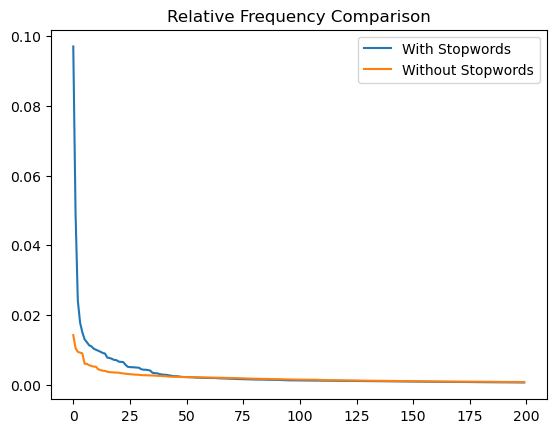

In [10]:
# Module 10: Relative Frequency Comparison

import matplotlib.pyplot as plt

start = start_timer()

top200_with['rel'] = top200_with['count'] / len(words)
top200_without['rel'] = top200_without['count'] / len(words_no_stop)

plt.figure()
plt.plot(top200_with['rel'].values, label="With Stopwords")
plt.plot(top200_without['rel'].values, label="Without Stopwords")
plt.legend()
plt.title("Relative Frequency Comparison")

end_timer(start, "Relative Frequency Plot")

## MODULE 11: Zipf Comparison

This module examines how word frequencies follow a well-known pattern in language called Zipf’s Law. First, each of the top 200 words is assigned a rank based on how common it is (1 = most frequent, 2 = second most frequent, etc.). The relative frequencies are then plotted against these ranks using a log-log scale, revealing patterns that are not easily visible on a regular chart. I plotted both versions of the data, with and without stopwords.

The graph shows a clear downward-sloping line for both versions of the data, indicating that the text follows Zipf’s Law: a small number of words are very common, while most are rare. The line with stopwords starts higher, meaning that the most frequent words (like “the” and “and”) dominate the text more strongly. The line without stopwords is lower and smoother, showing a more even distribution among meaningful words. As the lines move to the right, they begin to converge, indicating that less frequent words behave similarly in both datasets. Overall, this visualization confirms that natural language has a predictable structure.

[TIMER] Zipf Plot: 0.07 seconds


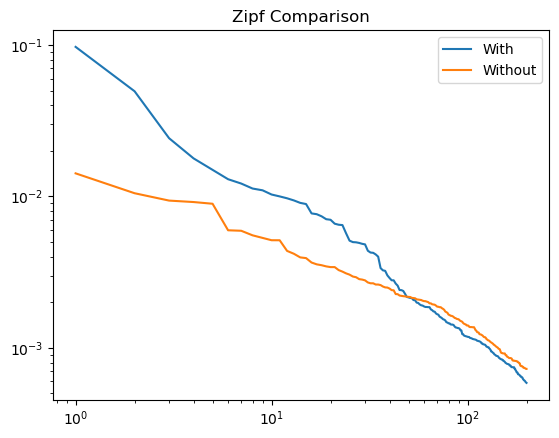

In [11]:
# Module 11: ZIPF Comparison

import numpy as np

start = start_timer()

ranks = np.arange(1, 201)

plt.figure()
plt.loglog(ranks, top200_with['rel'], label="With")
plt.loglog(ranks, top200_without['rel'], label="Without")
plt.legend()
plt.title("Zipf Comparison")

end_timer(start, "Zipf Plot")

## MODULE 12: Network (NO STOPWORDS)

This module builds a network of words based on how they appear together in the text. Each word is treated as a node, and an edge is created whenever two words appear next to each other within a small window. I looped through the cleaned list of words (with stopwords removed). My code captures these pairings and adds them to a network (using the networkx library). This creates a web of connections that reflects how words are related to one another in the text.

In [12]:
# Module 12: Network (No Stopwords)

import networkx as nx
from itertools import combinations

start = start_timer()

G = nx.Graph()

for i in range(len(words_no_stop)-2):
    window = words_no_stop[i:i+2]
    for w1, w2 in combinations(window,2):
        G.add_edge(w1,w2)

end_timer(start, "Network Construction")

[TIMER] Network Construction: 1.06 seconds


## MODULE 13: Centrality Comparison Table

This module analyzes the importance of words within the network by calculating different types of centrality. I only used the top 200 most important words to focus on meaningful connections. Three types of centrality are computed: degree, betweeness and eigenvector. Degree centrality measures how many direct connections a word has, showing how frequently it appears alongside other words. Betweenness centrality measures how often a word acts as a bridge between different groups of words, indicating its role in connecting ideas. Eigenvector centrality identifies words that are connected to other highly important words, capturing overall influence in the network. I organized the results into a table and sorted by eigenvector centrality, highlighting the most influential words in the entire network.

The words “god”, "said" and “king” rank one, two and three in succession as the highest words for **degree centrality**, **betweenness centrality**, and **eigenvector centrality**. Clearly, these words are the strongest words many other important words, making them central to the structure of the text. 

The high **degree centrality**, means they appeared alongside many different words. The high **betweenness centrality**, means they frequently connect different groups of words in the network. In other words, they are words that sit “in between” clusters of ideas. They play a key role in linking different themes or ideas throughout the text. The high **eigenvector centrality** means they are not only well-connected but are also connected to other important words. This makes them the most influential words in the network. The relatively close values among the top words indicate that influence is shared among several key terms rather than dominated by a single word. 

Other words, like "day', "man", "come', "came", and "son" had high centrality scores across all three metrics.

In [13]:
# Module 13: Centrality Comparison Table

start = start_timer()

top_words = set(top200_without['word'])
G_sub = G.subgraph(top_words)

deg = nx.degree_centrality(G_sub)
bet = nx.betweenness_centrality(G_sub)
eig = nx.eigenvector_centrality(G_sub, max_iter=1000)

centrality_df = pd.DataFrame({
    "degree": deg,
    "betweenness": bet,
    "eigenvector": eig
}).sort_values(by="eigenvector", ascending=False)

end_timer(start, "Centrality")

centrality_df.head(10)

[TIMER] Centrality: 10.88 seconds


,degree,betweenness,eigenvector
god,0.984925,0.008391,0.110006
said,0.969849,0.007654,0.109116
king,0.929648,0.006935,0.105316
lord,0.919598,0.006358,0.104989
day,0.914573,0.006644,0.103659
man,0.904523,0.006290,0.103260
come,0.894472,0.005581,0.103179
came,0.909548,0.006529,0.103104
son,0.899497,0.006718,0.102005
also,0.899497,0.006578,0.101844


## MODULE 14: Multi-Metric Plot

In this module, I wanted to visualize how the three different centrality measures—degree, betweenness, and eigenvector for the top influential words appeared on a side-by-side bar chart. Each word is displayed on the vertical axis, and three horizontal bars are shown for each metric.

This chart visually shows the degree centrality bars (blue) are consistently very high across all words, indicating that most of these top words are connected to a large number of other words. This confirms that the network is highly dense and that these words appear in many different contexts throughout the text.

The betweenness centrality values (orange) are very small and relatively similar across words. This suggests that while these words are highly connected, they do not differ dramatically in their role as bridges between clusters. In other words, the network is so interconnected that no single word dominates as a unique connector—many words share this role.

The eigenvector centrality values (green) provide the most meaningful differentiation. While the differences are subtle, they reveal which words are  embedded in the most important parts of the network. Words like “god” “said,” and “king” consistently rank highest, confirming that they connected to other influential words. 

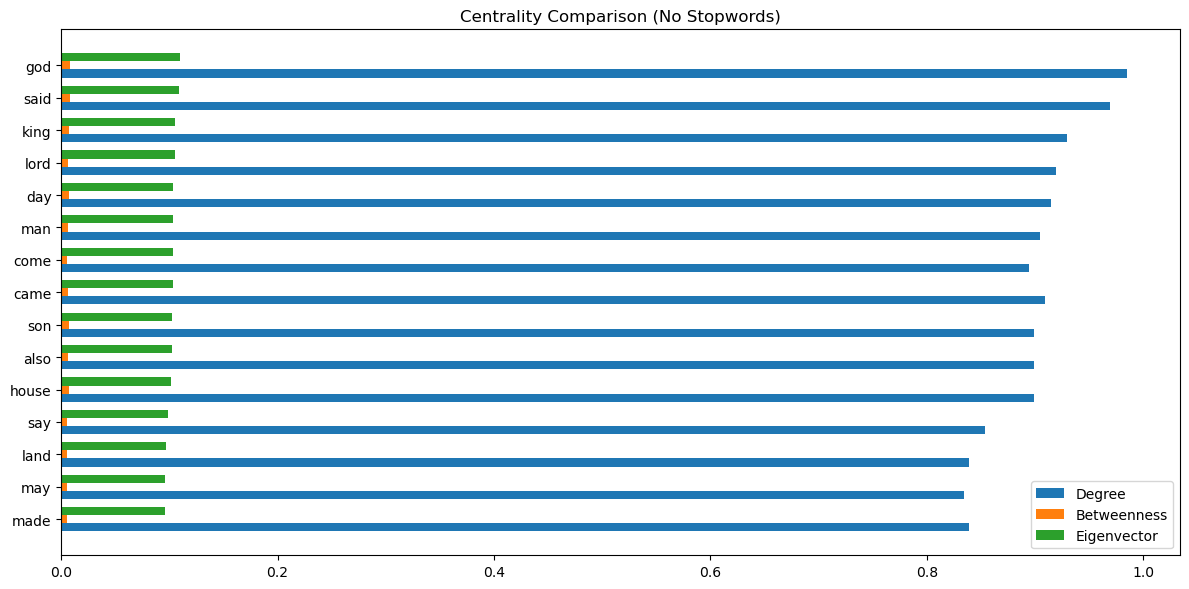

[TIMER] Multi-Metric Plot: 0.33 seconds


In [14]:
# Module 14: Multi-Metric Plot

start = start_timer()

plot_df = centrality_df.head(15)[::-1]

labels = [textwrap.fill(word, 10) for word in plot_df.index]

x = np.arange(len(labels))

plt.figure(figsize=(12,6))

plt.barh(x - 0.25, plot_df['degree'], height=0.25, label='Degree')
plt.barh(x, plot_df['betweenness'], height=0.25, label='Betweenness')
plt.barh(x + 0.25, plot_df['eigenvector'], height=0.25, label='Eigenvector')

plt.yticks(x, labels)

plt.legend()
plt.title("Centrality Comparison (No Stopwords)")

plt.tight_layout()
plt.show()

end_timer(start, "Multi-Metric Plot")

## MODULE 15: Influence Bar Chart

This module creates a horizontal bar chart to visually highlight the most influential words in the network based on eigenvector centrality. First, the top 15 words are plotted in top-down order on the chart. Numerical values are added next to each bar to make the chart easy to read and interpret. This visualization transforms the centrality table into a clear and intuitive summary of influence.

The chart visually shows that the words “god”, "said" and “king” rank one, two and three have the highest influence in the network.

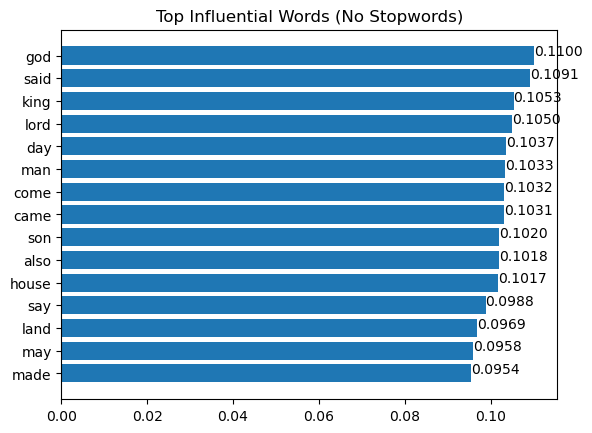

In [15]:
# Module 15: Influence Bar Chart

import textwrap

top = centrality_df.head(15)[::-1]

labels = [textwrap.fill(w,10) for w in top.index]

plt.figure()
plt.barh(labels, top['eigenvector'])
plt.title("Top Influential Words (No Stopwords)")

for i,v in enumerate(top['eigenvector']):
    plt.text(v,i,f"{v:.4f}")

plt.show()

## MODULE 16: Network Visualization of top 200 words

This module visualizes the word network by plotting all words (nodes) and their connections (edges). The spring_layout algorithm is used. The density of the graph indicates that words that are more closely connected are nearer to each other, while less connected words are farther apart. 

This network visualization reveals that the text is extremely dense and highly interconnected, with most words connected to many others. The large, tightly packed central cluster indicates that most words co-occur frequently. To me, this suggests that the text repeatedly combines a core set of concepts. This is not surprising and is typical of structured narratives, like religious or historical texts. Key ideas are reused and interconnected throughout the narrative.

The dense ball shape in the center means that important words are not isolated but consistently appear in similar contexts. This visualization supports earlier findings from frequency and centrality analysis that the text is dominated by a core vocabulary that drives meaning.

At the edges of the network, I observed a few nodes that are more loosely connected or positioned slightly outside the main cluster. These words may represent more specialized or context-specific terms that do not appear as broadly across the text. Their position suggests they are less central to the overall narrative, yet they still contribute to specific passages or themes.

The presence of many overlapping edges indicates that the network is close to being fully connected, meaning most words are directly or indirectly related. It is great to see the connectedness, but it is visually challenging to interpret. The difficulty in interpretation suggests the need for further refinement to reveal clearer substructures or clusters.

[TIMER] Network Plot: 0.84 seconds


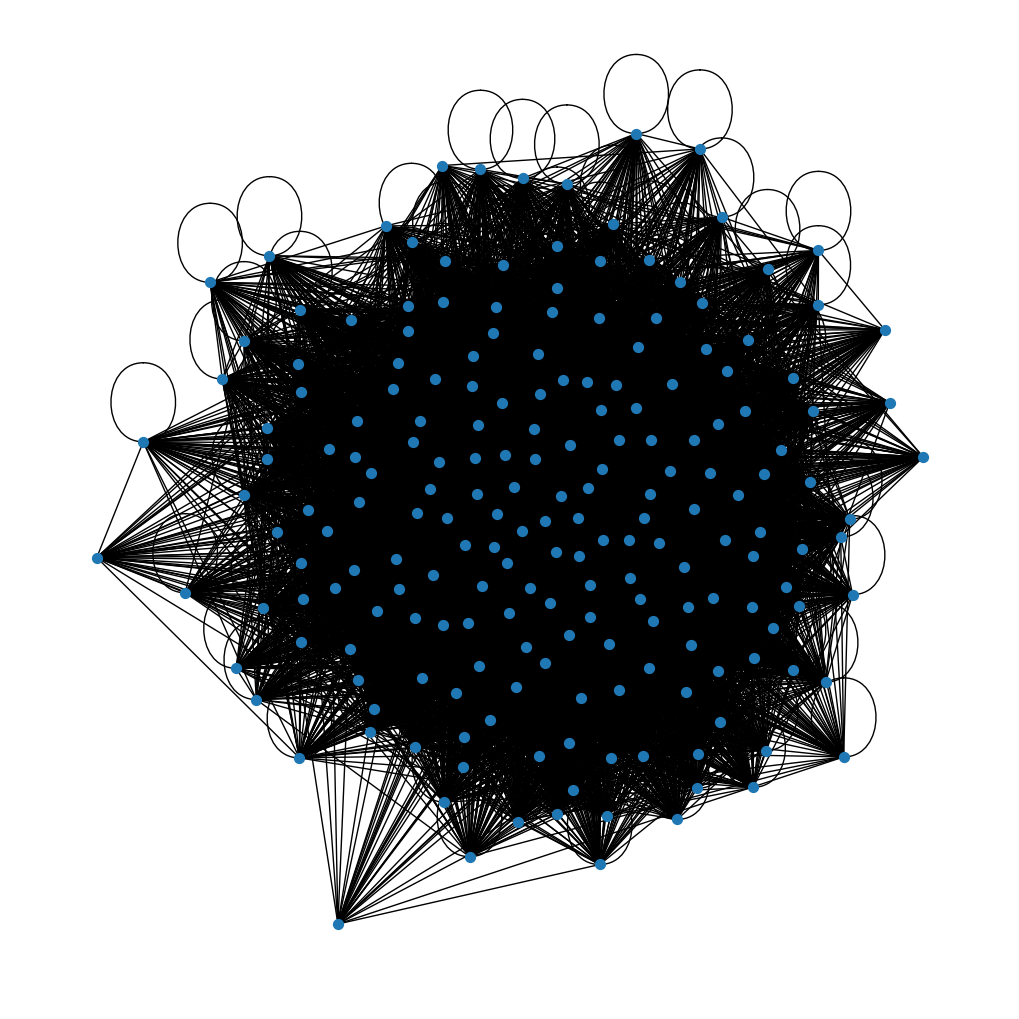

In [16]:
# Module 16: Network Visualization of top 200 words

start = start_timer()
np.random.seed(123)
plt.figure(figsize=(10,10))

pos = nx.spring_layout(G_sub, k=0.3)

nx.draw(G_sub, pos, node_size=50, with_labels=False)

end_timer(start, "Network Plot")

plt.show()